# COMSOL trap — full-chip top GND and local lower GND, no VIAS

Based on `COMSOL_75um_Trap.ipynb`. All in-plane lengths are in **µm**.

The RF rails retain their **77 µm upper / 92 µm lower** widths through the feeds.
The **92 µm vertical feed enters the midpoint of the RF bonding pad's bottom edge**.
The center DC extends to **8 µm before the RF return**. The existing bonding-pad
positions, segmented DC electrodes, and DC routing are retained.

There are two distinct metal layers:

- **7/0 — top metal:** RF/DC electrodes plus the restored full-chip top GND plane,
  with the guide's 8 µm electrode clearances, alignment cutouts, and waveguide opening.
- **8/0 — lower GND:** one solid rectangle under the trapping region, extending
  **200 µm beyond the segmented DC bounds on all four sides**. It has no RF/DC
  cutouts. `gnd_margin_x` and `gnd_margin_y` control its footprint.

GDS stores these as separate 2D layers. Set layer 8/0's vertical position and metal
thickness below the top metal in COMSOL, using your physical stack. No vertical
separation is assumed here, and no VIAS are constructed.

Use the existing **gdsfac** environment and **Run All** to check the geometry and
regenerate the preview and GDS beside this notebook. Existing output names are retained.


In [1]:
from pathlib import Path
from importlib.metadata import version

import gdsfactory as gf
import klayout.db as kdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as PlotPolygon

print(f"gdsfactory {version('gdsfactory')}; KLayout {version('klayout')}")


gdsfactory 8.2.3; KLayout 0.29.1


In [2]:
# Original guide parameters (µm).
electrode_gap = 8

die_width = 12000+2*electrode_gap       # Width of a single die
die_height = 6500+2*electrode_gap        # Height of a single die

#layer information
layer_metal = (9,0) # can flexibily change this
layer_trap = (7,0)  # Top RF/DC electrodes and full-chip top GND.
layer_lower_ground = (8,0)  # Separate lower GND; assign its z position in COMSOL.
layer_temp = (4,0)  # Guide alignment cutouts; not exported.

#electrode information
rf_rail_width = 92
center_dc_width = 77
# Preserve the guide's RF bonding-pad position independently of the DC length.
original_axial_length = 5500-409.13-electrode_gap+2110.13
rf_connect_length = 242

#pad size
rf_pad_size = 500
dc_pad_size_width = 400
dc_pad_size_length = 400

# Full-width rail dimensions are preserved from the actual guide polygon.
rf_top_rail_width = center_dc_width
rf_left_extension = 1000.0  # Beyond the leftmost segmented DC electrode.
# Both feeds keep their rail widths; the common return matches the wider rail.
rf_return_width = max(rf_top_rail_width, rf_rail_width)
rf_pad_xmin = original_axial_length + rf_connect_length - rf_pad_size
rf_pad_ymin = electrode_gap + 2 * center_dc_width + 300 - 75
rf_join_x = rf_pad_xmin + rf_pad_size / 2  # Vertical feed enters the pad at its midpoint.
rf_return_xmin = rf_join_x - rf_return_width / 2
rf_return_xmax = rf_join_x + rf_return_width / 2
dc_routing_width = 62

dc_small_trap_size=112
dc_big_trap_size=212

#trap width now is different!
dc_trap_width=134

top_electrode_spacing = 78

# Lower GND footprint: margins beyond the segmented trapping electrodes only.
gnd_margin_x = 200.0  # Left and right.
gnd_margin_y = 200.0  # Above and below.
# Scratch layers for the restored guide Boolean pipeline; not exported.
layer_bool_1 = (101, 0)
layer_bool_2 = (102, 0)
layer_bool_3 = (103, 0)
# Run from this notebook's directory; no absolute output path from the guide.
output_dir = Path.cwd()
output_path = output_dir / "comsol_trap_rf_1000um_no_vias.gds"
preview_path = output_dir / "comsol_trap_rf_1000um_no_vias.png"


## DC electrodes and their original routes
The segmented electrodes, pad positions, and routes come from the guide.
The center DC extends to the RF return with an `electrode_gap` clearance at its
right end. Explicit `d...` coordinates keep all placements in µm.


In [3]:
# Original segmented DC electrodes, pad positions, and routes from the guide.
# Reset the layout cache so Run All can be repeated in this kernel.
gf.clear_cache()
c_dc = gf.Component("dc_electrodes")

center_dc_ext_c = gf.Component()
center_dc_ext_c.add_polygon([(0, 0), (2400, 0), (2400, center_dc_width), (0, center_dc_width)], layer=layer_metal)
center_dc_ext_c.add_port(name="e1", center=[0 + dc_routing_width / 2, center_dc_width / 2], width=dc_routing_width, orientation=180, layer=layer_metal)
center_dc_ext = c_dc << center_dc_ext_c
center_dc_ext.dmovex(-2400)

top_DCs = c_dc << gf.components.pad_array(port_orientation=270, columns=11, spacing=(top_electrode_spacing + dc_pad_size_width, 0), size=(dc_pad_size_width, dc_pad_size_length), layer=layer_metal)
top_DCs.dmovex(-3000 - 483.13 + electrode_gap - 89.87 + 300).dmovey(2500 - 1000 - 14.18 + 661.25 - electrode_gap + 724.43 - 75)
xs_center = gf.cross_section.cross_section(width=center_dc_width, layer=layer_metal)
gf.routing.route_single_electrical(c_dc, center_dc_ext['e1'], top_DCs['e11'], cross_section=xs_center, start_straight_length=100)

top_DCs_trap_1 = c_dc << gf.components.pad_array(port_orientation=90, columns=5, spacing=(electrode_gap + dc_small_trap_size, 0), size=(dc_small_trap_size, dc_trap_width), layer=layer_metal)
top_DCs_trap_1.dmovex(1000 + dc_small_trap_size / 2 + 28.87).dmovey(2 * electrode_gap + 2 * center_dc_width + dc_trap_width / 2)

xs_dc = gf.cross_section.cross_section(width=dc_routing_width, layer=layer_metal)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_1['e11'], top_DCs['e12'], cross_section=xs_dc, start_straight_length=200 - 50 - 13 - 5 + 10 + 360.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_1['e12'], top_DCs['e13'], cross_section=xs_dc, start_straight_length=300 - 50 - 1 + 45 + 10 + 376.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_1['e13'], top_DCs['e14'], cross_section=xs_dc, start_straight_length=400 - 39 + 95 + 10 + 392.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_1['e14'], top_DCs['e15'], cross_section=xs_dc, start_straight_length=500 + 118 + 10 + 408.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_1['e15'], top_DCs['e16'], cross_section=xs_dc, start_straight_length=600 + 190 + 424.5)

top_DCs_trap_2 = c_dc << gf.components.pad_array(port_orientation=90, columns=2, spacing=(electrode_gap + dc_big_trap_size, 0), size=(dc_big_trap_size, dc_trap_width), layer=layer_metal)
top_DCs_trap_2.dmovex(top_DCs_trap_1.dxmax + electrode_gap + dc_big_trap_size / 2).dmovey(2 * electrode_gap + 2 * center_dc_width + dc_trap_width / 2)

top_DCs_trap_3 = c_dc << gf.components.pad_array(port_orientation=90, columns=1, spacing=(electrode_gap + dc_small_trap_size, 0), size=(dc_small_trap_size, dc_trap_width), layer=layer_metal)
top_DCs_trap_3.dmovex(top_DCs_trap_2.dxmax + electrode_gap + dc_small_trap_size / 2).dmovey(2 * electrode_gap + 2 * center_dc_width + dc_trap_width / 2)

top_DCs_trap_4 = c_dc << gf.components.pad_array(port_orientation=90, columns=2, spacing=(electrode_gap + dc_big_trap_size, 0), size=(dc_big_trap_size, dc_trap_width), layer=layer_metal)
top_DCs_trap_4.dmovex(top_DCs_trap_3.dxmax + electrode_gap + dc_big_trap_size / 2).dmovey(2 * electrode_gap + 2 * center_dc_width + dc_trap_width / 2)

gf.routing.route_single_electrical(c_dc, top_DCs_trap_2['e11'], top_DCs['e17'], cross_section=xs_dc, start_straight_length=700 + 252 + 440.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_2['e12'], top_DCs['e18'], cross_section=xs_dc, start_straight_length=800 + 314 + 456.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_3['e11'], top_DCs['e19'], cross_section=xs_dc, start_straight_length=900 + 376 + 472.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_4['e11'], top_DCs['e110'], cross_section=xs_dc, start_straight_length=1438 + 488.5)
gf.routing.route_single_electrical(c_dc, top_DCs_trap_4['e12'], top_DCs['e111'], cross_section=xs_dc, start_straight_length=1600 - 40 + 544.5)

bot_DCs = c_dc << gf.components.pad_array(port_orientation=90, columns=10, spacing=(top_electrode_spacing + dc_pad_size_width, 0), size=(dc_pad_size_width, dc_pad_size_length), layer=layer_metal)
bot_DCs.dmovex(700 + 1080 + 800 - 125 + 478).dmovey(-1300 - 827.67 + 661.25 + electrode_gap - 60 - 40 + 22.42 - 20 - 10 - 1145.5)

bot_DCs_trap_1 = c_dc << gf.components.pad_array(port_orientation=270, columns=5, spacing=(electrode_gap + dc_small_trap_size, 0), size=(dc_small_trap_size, dc_trap_width), layer=layer_metal)
bot_DCs_trap_1.dmovex(1000 + dc_small_trap_size / 2 + 28.87).dmovey(-2 * electrode_gap - rf_rail_width - dc_trap_width / 2)

gf.routing.route_single_electrical(c_dc, bot_DCs_trap_1['e11'], bot_DCs['e11'], cross_section=xs_dc, start_straight_length=1100 + 63.42 - 103.001 + 700 + 29.08 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_1['e12'], bot_DCs['e12'], cross_section=xs_dc, start_straight_length=920 + 28.42 + 675 - 11.92 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_1['e13'], bot_DCs['e13'], cross_section=xs_dc, start_straight_length=810 - 9 + 675 - 42.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_1['e14'], bot_DCs['e14'], cross_section=xs_dc, start_straight_length=700 - 1 + 600 - 43.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_1['e15'], bot_DCs['e15'], cross_section=xs_dc, start_straight_length=600 - 3 + 500 - 19.5 + 300 - 165)

bot_DCs_trap_2 = c_dc << gf.components.pad_array(port_orientation=270, columns=2, spacing=(electrode_gap + dc_big_trap_size, 0), size=(dc_big_trap_size, dc_trap_width), layer=layer_metal)
bot_DCs_trap_2.dmovex(bot_DCs_trap_1.dxmax + electrode_gap + dc_big_trap_size / 2).dmovey(-2 * electrode_gap - rf_rail_width - dc_trap_width / 2)

bot_DCs_trap_3 = c_dc << gf.components.pad_array(port_orientation=270, columns=1, spacing=(electrode_gap + dc_small_trap_size, 0), size=(dc_small_trap_size, dc_trap_width), layer=layer_metal)
bot_DCs_trap_3.dmovex(bot_DCs_trap_2.dxmax + electrode_gap + dc_small_trap_size / 2).dmovey(-2 * electrode_gap - rf_rail_width - dc_trap_width / 2)

bot_DCs_trap_4 = c_dc << gf.components.pad_array(port_orientation=270, columns=2, spacing=(electrode_gap + dc_big_trap_size, 0), size=(dc_big_trap_size, dc_trap_width), layer=layer_metal)
bot_DCs_trap_4.dmovex(bot_DCs_trap_3.dxmax + electrode_gap + dc_big_trap_size / 2).dmovey(-2 * electrode_gap - rf_rail_width - dc_trap_width / 2)

gf.routing.route_single_electrical(c_dc, bot_DCs_trap_2['e11'], bot_DCs['e16'], cross_section=xs_dc, start_straight_length=500 - 5 + 404.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_2['e12'], bot_DCs['e17'], cross_section=xs_dc, start_straight_length=400 - 7 + 328.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_3['e11'], bot_DCs['e18'], cross_section=xs_dc, start_straight_length=300 - 9 + 252.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_4['e11'], bot_DCs['e19'], cross_section=xs_dc, start_straight_length=200 - 13 + 2 + 176.5 + 300 - 165)
gf.routing.route_single_electrical(c_dc, bot_DCs_trap_4['e12'], bot_DCs['e110'], cross_section=xs_dc, start_straight_length=100 - 13 + 100.5 + 300 - 165)

# Locate the segmented DCs, then extend the center DC up to the RF return.
dc_trap_refs = [
    top_DCs_trap_1, top_DCs_trap_2, top_DCs_trap_3, top_DCs_trap_4,
    bot_DCs_trap_1, bot_DCs_trap_2, bot_DCs_trap_3, bot_DCs_trap_4,
]
dc_xmin = min(ref.dxmin for ref in dc_trap_refs)
dc_xmax = max(ref.dxmax for ref in dc_trap_refs)

center_dc_xmax = rf_return_xmin - electrode_gap
assert center_dc_xmax > dc_xmax, "RF return leaves no center DC overhang."
center_dc = c_dc << gf.components.rectangle(
    size=(center_dc_xmax, center_dc_width), layer=layer_metal
)


## Full-width RF feeds centered on the bonding pad
The return is centered at `rf_pad_xmin + rf_pad_size / 2`, so the vertical feed
enters the middle of the pad's bottom edge. The center DC endpoint automatically
keeps an 8 µm clearance from this return. Both horizontal feeds retain their rail widths.


In [4]:
rf_xmin = dc_xmin - rf_left_extension
rf_xmax = rf_return_xmax

assert rf_left_extension > 0
assert min(rf_top_rail_width, rf_rail_width, rf_return_width) > 0
assert rf_xmin < rf_return_xmin
assert np.isclose(rf_return_xmin - center_dc.dxmax, electrode_gap)
assert rf_pad_xmin <= rf_return_xmin
assert rf_return_xmax <= rf_pad_xmin + rf_pad_size

c_rf = gf.Component("rf_rails_and_feed")

def add_rf_rail(ymin, width):
    """A continuous full-width rail and feed, without a taper or width step."""
    c_rf.add_polygon([
        (rf_xmin, ymin),
        (rf_xmax, ymin),
        (rf_xmax, ymin + width),
        (rf_xmin, ymin + width),
    ], layer=layer_metal)
    return ymin + width / 2

rf_top_y = add_rf_rail(electrode_gap + center_dc_width, rf_top_rail_width)
rf_bottom_y = add_rf_rail(-electrode_gap - rf_rail_width, rf_rail_width)

# The common return matches the wider rail and overlaps the RF pad.
c_rf.add_polygon([
    (rf_return_xmin, -electrode_gap - rf_rail_width),
    (rf_return_xmax, -electrode_gap - rf_rail_width),
    (rf_return_xmax, rf_pad_ymin + rf_return_width / 2),
    (rf_return_xmin, rf_pad_ymin + rf_return_width / 2),
], layer=layer_metal)
rf_pad = c_rf << gf.components.rectangle(
    size=(rf_pad_size, rf_pad_size), layer=layer_metal
)
rf_pad.dmovex(rf_pad_xmin).dmovey(rf_pad_ymin)
assert np.isclose(rf_join_x, rf_pad.dx), "RF feed must enter the middle of the RF pad."

c_trap = gf.Component("trap_electrodes")
c_trap << c_dc
c_trap << c_rf

print(f"Segmented DC span: {dc_xmin:.3f} to {dc_xmax:.3f} µm")
print(f"RF rails and feeds: {rf_top_rail_width:g} µm upper / {rf_rail_width:g} µm lower; no width change")
print(f"Full-width RF span: {rf_xmin:.3f} to {rf_xmax:.3f} µm")
print(f"Center DC right endpoint: {center_dc.dxmax:.3f} µm "
      f"({center_dc.dxmax - dc_xmax:.3f} µm beyond the segmented DCs)")
print(f"Center DC to RF return gap: {rf_return_xmin - center_dc.dxmax:g} µm")

print(f"RF vertical feed / pad center x: {rf_join_x:.3f} / {rf_pad.dx:.3f} µm")


Segmented DC span: 1028.870 to 2620.870 µm
RF rails and feeds: 77 µm upper / 92 µm lower; no width change
Full-width RF span: 28.870 to 7231.000 µm
Center DC right endpoint: 7131.000 µm (4510.130 µm beyond the segmented DCs)
Center DC to RF return gap: 8 µm
RF vertical feed / pad center x: 7185.000 / 7185.000 µm


## Full-chip top GND and a separate local lower GND plane
Restore the guide's top ground construction, including its alignment cutouts and
waveguide opening. Its electrode clearance remains 8 µm. The final top mask is on 7/0.

The lower GND is a **single solid rectangle on 8/0**, using the segmented DC bounds
plus 200 µm on all sides. Because it is on a different physical level, it is not
carved around the top electrodes or routes. `c_top_ground` and `c_lower_ground`
retain the two ground geometries separately for inspection.


In [5]:
# --- 3. Build Alignment Marks Container (c_marks) ---
c_marks = gf.Component("alignment_marks")

step_1 = c_marks << gf.components.litho_steps(line_widths=(4, 8, 16, 32), line_spacing=10, height=500, layer=layer_temp)
step_2 = c_marks << gf.components.litho_steps(line_widths=(4, 8, 16, 32), line_spacing=10, height=500, layer=layer_temp)

step_1.dmovex(-4500 - 500 + 1700).dmovey(-2000)
step_2.dmovex(3500 + 1734 + 500).dmovey(2000)

# Group 1 Crosses
align_ox_m_1 = c_marks << gf.components.rectangle((100,100), layer=layer_temp, centered=True)
align_ox_m_2 = c_marks << gf.components.cross(length=100, width=28, layer=layer_temp)
align_ox_m_3 = c_marks << gf.components.cross(length=100, width=14, layer=layer_temp)

align_window_1 = c_marks << gf.components.rectangle((1200,300), layer=layer_temp, centered=True);
align_window_2 = c_marks << gf.components.rectangle((300,300), layer=layer_temp, centered=True);
align_window_3 = c_marks << gf.components.rectangle((1200,300), layer=layer_temp, centered=True);
align_window_4 = c_marks << gf.components.rectangle((300,300), layer=layer_temp, centered=True);

align_window_1.dmovex(step_1.dxmax +950).dmovey(-1732-43);
align_window_2.dmovex(align_ox_m_3.dxmin - 1000-300-1690).dmovey(-2000);
align_window_3.dmovex(step_1.dxmax +950).dmovey(-1732-42.5-1000+549.5);
align_window_4.dmovex(align_ox_m_3.dxmin-1390).dmovey(-2000);

align_ox_m_1.dmovex(step_1.dxmax + 1500).dmovey(step_1.dy)
align_ox_m_2.dmovex(align_ox_m_1.dxmin - 500).dmovey(step_1.dy)
align_ox_m_3.dmovex(align_ox_m_2.dxmin - 500).dmovey(step_1.dy)

# Group 2 Crosses
align_ox_m_4 = c_marks << gf.components.cross(length=100, width=14, layer=layer_temp)
align_ox_m_5 = c_marks << gf.components.cross(length=100, width=28, layer=layer_temp)
align_ox_m_6 = c_marks << gf.components.rectangle(size=(100, 100), layer=layer_temp, centered=True)

align_ox_m_4.dmovex(step_2.dxmax + 1500).dmovey(step_2.dy)
align_ox_m_5.dmovex(align_ox_m_4.dxmin - 500).dmovey(step_2.dy)
align_ox_m_6.dmovex(align_ox_m_5.dxmin - 500).dmovey(step_2.dy)

align_window_5 = c_marks << gf.components.rectangle((1200,300), layer=layer_temp, centered=True);
align_window_6 = c_marks << gf.components.rectangle((300,300), layer=layer_temp, centered=True);
align_window_5.dmovex(step_2.dxmax +950).dmovey(+1732+43+450);
align_window_6.dmovex(align_ox_m_6.dxmin - 1000-300-1690+2790).dmovey(2000);

wg_open = c_marks << gf.components.rectangle((500,6500+100), layer=layer_temp, centered=True);
wg_open.dmovex(-4015)

# --- 4. Apply Spatial Translations via References ---
shift_x = -1735
shift_y = -center_dc_width / 2

# Instantiate into shifted containers to move the References cleanly
c_trap_shifted = gf.Component("trap_electrodes_shifted")
ref_trap = c_trap_shifted << c_trap
ref_trap.dmovex(shift_x).dmovey(shift_y)

c_marks_shifted = gf.Component("alignment_marks_shifted")
ref_marks = c_marks_shifted << c_marks
ref_marks.dmovex(shift_x).dmovey(shift_y)


# --- 5. Clean Boolean & Trench Sizing Pipeline ---
# Create an independent die background container
c_bg = gf.Component("die_background")
die_border = c_bg << gf.components.rectangle(size=(die_width, die_height), layer=(0, 0))
die_border.dcenter = (0, 0)

# Step A: Carve electrodes out of the die border
c_inv = gf.boolean(
    A=c_bg,
    B=c_trap_shifted,      
    operation="not",      
    layer1=(0, 0),        
    layer2=layer_metal,        
    layer=layer_bool_1        
)

# Step B: Isotropically shrink the inverted background by electrode_gap (widens the isolation trenches)
layout_inv = c_inv.layout()
region_inv = kdb.Region(c_inv.begin_shapes_rec(layout_inv.layer(layer_bool_1)))
shrunk_region = region_inv.sized(-round(electrode_gap / layout_inv.dbu))

# Place shrunk background into an intermediate container on scratchpad layer
c_shrunk = gf.Component("shrunk_background")
layout_shrunk = c_shrunk.layout()
c_shrunk.shapes(layout_shrunk.layer(layer_bool_2)).insert(shrunk_region)

# Step C: Carve the litho steps and crosses out of the shrunk ground plane
c_bg_with_marks = gf.boolean(
    A=c_shrunk,
    B=c_marks_shifted,     
    operation="not",      
    layer1=layer_bool_2,        
    layer2=layer_temp,        
    layer=layer_bool_3           
)

# Step D: Combine (Boolean OR) the ground plane WITH the actual electrodes to create the total metal mask!
c_final_mask = gf.boolean(
    A=c_bg_with_marks,
    B=c_trap_shifted,
    operation="or",        # Union combines both geometries into one single mask
    layer1=layer_bool_3,
    layer2=layer_metal,
    layer=layer_trap       # Directly output to your final target layer (7, 0)
)


# Preserve the top GND separately from the combined top metal mask.
c_top_ground = c_bg_with_marks

# Solid lower plane: bounds follow only the segmented trapping electrodes.
assert gnd_margin_x > 0 and gnd_margin_y > 0
assert layer_lower_ground != layer_trap
dc_ymin = min(ref.dymin for ref in dc_trap_refs)
dc_ymax = max(ref.dymax for ref in dc_trap_refs)
gnd_xmin = dc_xmin - gnd_margin_x + shift_x
gnd_xmax = dc_xmax + gnd_margin_x + shift_x
gnd_ymin = dc_ymin - gnd_margin_y + shift_y
gnd_ymax = dc_ymax + gnd_margin_y + shift_y

c_lower_ground = gf.Component("local_lower_ground")
lower_ground = c_lower_ground << gf.components.rectangle(
    size=(gnd_xmax - gnd_xmin, gnd_ymax - gnd_ymin), layer=layer_lower_ground
)
lower_ground.dmovex(gnd_xmin).dmovey(gnd_ymin)

c_main = gf.Component("comsol_rf_1000um_no_vias")
c_main << c_final_mask
c_main << c_lower_ground

print(f"Top layer {layer_trap}: restored full-chip GND and RF/DC electrodes")
print(f"Lower layer {layer_lower_ground}: one solid GND rectangle, no electrode cutouts")
print(f"Lower GND margins: {gnd_margin_x:g} µm left/right; {gnd_margin_y:g} µm above/below")
print(f"Lower GND size: {gnd_xmax - gnd_xmin:g} × {gnd_ymax - gnd_ymin:g} µm")
print("Set the lower layer's z position and thickness in COMSOL to match the physical stack.")


Top layer (7, 0): restored full-chip GND and RF/DC electrodes
Lower layer (8, 0): one solid GND rectangle, no electrode cutouts
Lower GND margins: 200 µm left/right; 200 µm above/below
Lower GND size: 1992 × 946 µm
Set the lower layer's z position and thickness in COMSOL to match the physical stack.


## Geometry checks
Check RF continuity, rail/feed widths, centered pad entry, and all top-metal
clearances. Verify that the full-chip top GND is restored and that the lower GND is
one unbroken rectangle on its own layer. These are 2D layout checks, not an RF simulation.


In [6]:
def region_of(component, layer):
    return kdb.Region(
        component.begin_shapes_rec(component.layout().layer(layer))
    ).merged()

dbu = c_main.layout().dbu
rf_region = region_of(c_rf, layer_metal)
dc_region = region_of(c_dc, layer_metal)
metal_region = region_of(c_main, layer_trap)
electrode_region = region_of(c_trap_shifted, layer_metal)
ground_region = region_of(c_top_ground, layer_bool_3)
lower_ground_region = region_of(c_lower_ground, layer_lower_ground)

assert np.isclose(dc_xmin - rf_xmin, rf_left_extension, atol=dbu, rtol=0)
assert np.isclose(rf_return_xmin - center_dc.dxmax, electrode_gap, atol=dbu, rtol=0)
assert center_dc.dxmax > dc_xmax
assert np.isclose(rf_join_x, rf_pad.dx, atol=dbu, rtol=0), "RF pad entry is off-center."
assert rf_region.count() == 1, "The RF rails, feed, and pad must be connected."
assert dc_region.count() == 21, "Expected 20 segmented DC nets plus the center DC."
assert (rf_region & dc_region).is_empty(), "RF/DC short."
clearance_dbu = round(electrode_gap / dbu)
assert (rf_region.sized(clearance_dbu - 1) & dc_region).is_empty(), "RF/DC gap too small."
assert (electrode_region - metal_region).is_empty(), "Electrode metal lost in mask."
assert (ground_region & electrode_region).is_empty(), "Ground/electrode overlap."
assert (ground_region.sized(clearance_dbu - 1) & electrode_region).is_empty(), "Ground gap too small."

def box_region(xmin, ymin, xmax, ymax):
    return kdb.Region(kdb.Box(*(round(v / dbu) for v in (xmin, ymin, xmax, ymax))))

expected_lower_ground = box_region(gnd_xmin, gnd_ymin, gnd_xmax, gnd_ymax)
assert lower_ground_region.count() == 1, "Lower GND must be a single connected plane."
assert (lower_ground_region ^ expected_lower_ground).is_empty(), "Lower GND must be a solid rectangle with the requested margins."
assert np.allclose([
    dc_xmin + shift_x - gnd_xmin, gnd_xmax - dc_xmax - shift_x,
    dc_ymin + shift_y - gnd_ymin, gnd_ymax - dc_ymax - shift_y,
], [gnd_margin_x, gnd_margin_x, gnd_margin_y, gnd_margin_y], atol=dbu, rtol=0)
assert not (lower_ground_region & electrode_region).is_empty(), "Lower GND should project beneath the top electrodes."
assert not ground_region.is_empty(), "Top GND is empty."
assert not (ground_region - expected_lower_ground).is_empty(), "Top GND was incorrectly limited to the local footprint."

# Check the full guide top-ground footprint, including its original cutouts.
die_region = region_of(c_bg, (0, 0))
marks_region = region_of(c_marks_shifted, layer_temp)
expected_top_ground = ((die_region - electrode_region).sized(-clearance_dbu) - marks_region).merged()
assert (ground_region ^ expected_top_ground).is_empty(), "Top GND differs from the restored guide construction."
assert (metal_region ^ (electrode_region | ground_region)).is_empty(), "Unexpected top metal."
assert (region_of(c_main, layer_lower_ground) ^ lower_ground_region).is_empty(), "Lower GND changed during assembly."

# The feed occupies the middle 92 µm of the pad's bottom edge.
pad_entry_window = box_region(rf_pad.dxmin, rf_pad.dymin - 2 * electrode_gap,
                              rf_pad.dxmax, rf_pad.dymin)
expected_entry = box_region(rf_pad.dx - rf_return_width / 2, rf_pad.dymin - 2 * electrode_gap,
                            rf_pad.dx + rf_return_width / 2, rf_pad.dymin)
assert ((rf_region & pad_entry_window) ^ expected_entry).is_empty(), "Incorrect RF pad entry."

for rail_ymin, rail_width in [
    (electrode_gap + center_dc_width, rf_top_rail_width),
    (-electrode_gap - rf_rail_width, rf_rail_width),
]:
    full_rail = box_region(rf_xmin, rail_ymin, rf_xmax, rail_ymin + rail_width)
    assert (full_rail - rf_region).is_empty(), "RF rail/feed has a narrowing or break."
    # Inspect the feed beyond the segmented DCs, before the common return.
    feed_window = box_region(dc_xmax, rail_ymin - electrode_gap,
                             rf_return_xmin, rail_ymin + rail_width + electrode_gap)
    expected_feed = box_region(dc_xmax, rail_ymin,
                               rf_return_xmin, rail_ymin + rail_width)
    assert ((rf_region & feed_window) ^ expected_feed).is_empty(), "RF feed must match the rail width."

assert set(c_main.layers) == {layer_trap, layer_lower_ground}, f"Unexpected export layers: {c_main.layers}"
print(f"PASS: RF feeds retain {rf_top_rail_width:g} / {rf_rail_width:g} µm rail widths throughout.")
print(f"PASS: centered RF pad entry; center DC ends {electrode_gap:g} µm before the return.")
print("PASS: original full-chip top GND restored, with electrode clearances and guide cutouts.")
print(f"PASS: one solid lower GND on {layer_lower_ground}, with {gnd_margin_x:g} / {gnd_margin_y:g} µm margins.")
print("PASS: one connected RF net, 21 DC nets, and at least 8 µm RF/DC and ground gaps.")
print(f"PASS: top/lower layers {layer_trap} and {layer_lower_ground}; no VIAS or temporary layers.")


PASS: RF feeds retain 77 / 92 µm rail widths throughout.
PASS: centered RF pad entry; center DC ends 8 µm before the return.
PASS: original full-chip top GND restored, with electrode clearances and guide cutouts.
PASS: one solid lower GND on (8, 0), with 200 / 200 µm margins.
PASS: one connected RF net, 21 DC nets, and at least 8 µm RF/DC and ground gaps.
PASS: top/lower layers (7, 0) and (8, 0); no VIAS or temporary layers.


## Preview of the two metal levels
The upper view shows the restored top GND (gray), RF (orange), and DC (blue).
The purple outline marks the lower plane's footprint beneath the top layer.
The lower-left view shows layer 8/0 alone: one continuous rectangle. The dotted
box indicates the segmented DC footprint above it for alignment only.


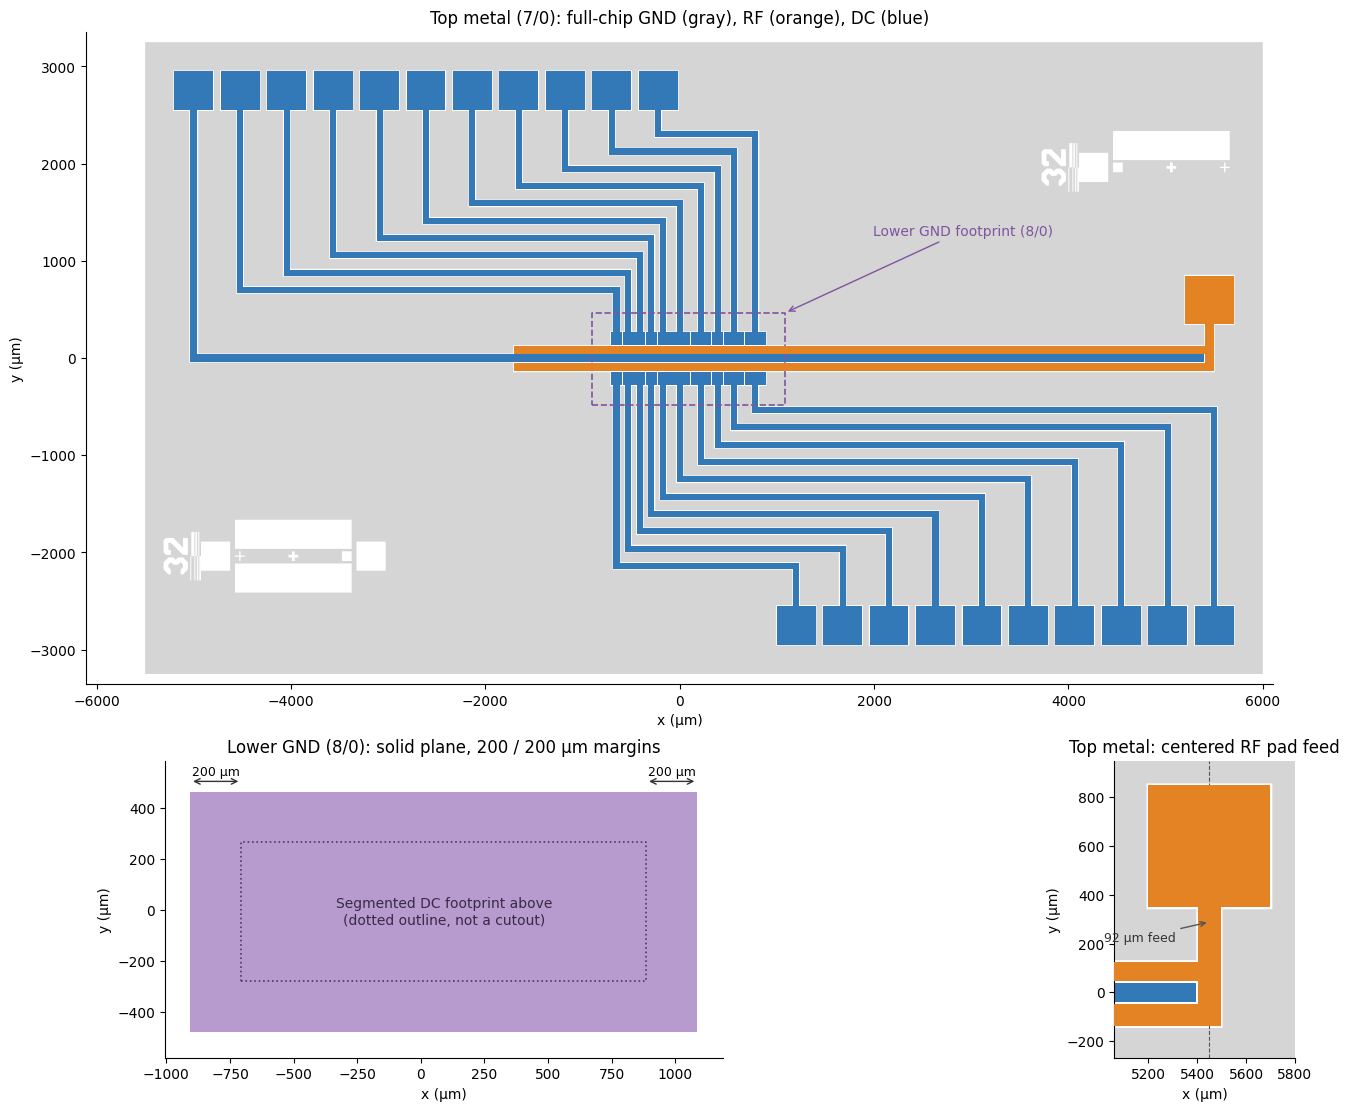

In [7]:
def draw_component(ax, component, layer, color, shift=(0, 0), zorder=1):
    polygons = component.get_polygons_points(merge=True, by="tuple").get(layer, [])
    for points in polygons:
        ax.add_patch(PlotPolygon(np.asarray(points) + np.asarray(shift),
                                closed=True, facecolor=color, edgecolor="none",
                                zorder=zorder))

def outline(ax, xmin, ymin, xmax, ymax, color, style="--"):
    ax.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin],
            color=color, linestyle=style, linewidth=1.2)

fig = plt.figure(figsize=(15, 11), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], width_ratios=[3, 1.3])
ax_all = fig.add_subplot(grid[0, :])
ax_lower = fig.add_subplot(grid[1, 0])
ax_pad = fig.add_subplot(grid[1, 1])

for ax in (ax_all, ax_pad):
    draw_component(ax, c_top_ground, layer_bool_3, "#d5d5d5")
    draw_component(ax, c_dc, layer_metal, "#3379b7", (shift_x, shift_y), zorder=2)
    draw_component(ax, c_rf, layer_metal, "#e38324", (shift_x, shift_y), zorder=3)
for ax in (ax_all, ax_lower, ax_pad):
    ax.set_aspect("equal")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.spines[["top", "right"]].set_visible(False)

ax_all.set_xlim(-die_width / 2 - 100, die_width / 2 + 100)
ax_all.set_ylim(-die_height / 2 - 100, die_height / 2 + 100)
ax_all.set_title("Top metal (7/0): full-chip GND (gray), RF (orange), DC (blue)")
outline(ax_all, gnd_xmin, gnd_ymin, gnd_xmax, gnd_ymax, "#8054a0")
ax_all.annotate("Lower GND footprint (8/0)", xy=(gnd_xmax, gnd_ymax),
                xytext=(gnd_xmax + 900, gnd_ymax + 800),
                arrowprops={"arrowstyle": "->", "color": "#8054a0"}, color="#8054a0")

draw_component(ax_lower, c_lower_ground, layer_lower_ground, "#b79bce")
outline(ax_lower, dc_xmin + shift_x, dc_ymin + shift_y,
        dc_xmax + shift_x, dc_ymax + shift_y, "#4f3862", ":")
ax_lower.set_xlim(gnd_xmin - 100, gnd_xmax + 100)
ax_lower.set_ylim(gnd_ymin - 100, gnd_ymax + 120)
ax_lower.set_title(f"Lower GND (8/0): solid plane, {gnd_margin_x:g} / {gnd_margin_y:g} µm margins")
ax_lower.text((gnd_xmin + gnd_xmax) / 2, (gnd_ymin + gnd_ymax) / 2,
              "Segmented DC footprint above\n(dotted outline, not a cutout)",
              ha="center", va="center", color="#382947", fontsize=10)
dimension_y = gnd_ymax + 40
for start, stop in [(gnd_xmin, dc_xmin + shift_x), (dc_xmax + shift_x, gnd_xmax)]:
    ax_lower.annotate("", xy=(start, dimension_y), xytext=(stop, dimension_y),
                      arrowprops={"arrowstyle": "<->", "color": "#333333"})
    ax_lower.text((start + stop) / 2, dimension_y + 12, f"{gnd_margin_x:g} µm",
                  ha="center", va="bottom", fontsize=9)

pad_center_x = rf_pad.dx + shift_x
ax_pad.axvline(pad_center_x, color="#555555", linestyle="--", linewidth=0.8)
ax_pad.set_xlim(rf_pad.dxmin + shift_x - 140, rf_pad.dxmax + shift_x + 100)
ax_pad.set_ylim(rf_bottom_y - rf_rail_width / 2 + shift_y - 130,
                rf_pad.dymax + shift_y + 100)
ax_pad.set_title("Top metal: centered RF pad feed")
ax_pad.annotate(f"{rf_return_width:g} µm feed", xy=(pad_center_x, rf_pad.dymin + shift_y - 60),
                xytext=(pad_center_x - 140, rf_pad.dymin + shift_y - 140), ha="right",
                arrowprops={"arrowstyle": "->", "color": "#555555"}, color="#333333", fontsize=9)
fig.savefig(preview_path, dpi=180)
plt.show()


## Export both metal levels for COMSOL
The GDS contains **7/0 (top metal and top GND)** and **8/0 (solid lower GND)**.
Both layers are reopened and compared with their source geometry. In COMSOL,
place the lower layer below the top layer at the separation and thickness of your
physical stack. The GDS does not encode their vertical separation.
To open the planar layout in KLayout, run `c_main.show()` separately if desired.


In [8]:
c_main.write_gds(output_path)

export_layout = kdb.Layout()
export_layout.read(str(output_path))
export_top = export_layout.top_cell()
export_layers = {
    (export_layout.get_info(index).layer, export_layout.get_info(index).datatype)
    for index in export_layout.layer_indexes()
    if not kdb.Region(export_top.begin_shapes_rec(index)).is_empty()
}
assert export_layers == {layer_trap, layer_lower_ground}, f"Unexpected GDS layers: {export_layers}"
assert np.isclose(export_layout.dbu, dbu)
for layer, expected_region in [(layer_trap, metal_region), (layer_lower_ground, lower_ground_region)]:
    exported_region = kdb.Region(
        export_top.begin_shapes_rec(export_layout.layer(*layer))
    ).merged()
    assert (exported_region ^ expected_region).is_empty(), f"GDS round-trip changed layer {layer}."
print(f"GDS: {output_path}")
print(f"Preview: {preview_path}")
print(f"Verified exported layers: {sorted(export_layers)}; no VIAS.")


GDS: /Users/yiyangzhi/GIT/integrated_trapped_ions/Fabrications/OPTICAL_GEN3_Trap/comsol_trap_rf_1000um_no_vias.gds
Preview: /Users/yiyangzhi/GIT/integrated_trapped_ions/Fabrications/OPTICAL_GEN3_Trap/comsol_trap_rf_1000um_no_vias.png
Verified exported layers: [(7, 0), (8, 0)]; no VIAS.
